In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [ ]:
df = pd.read_csv("Data/processed_data.csv")

df.head()

,transaction_id,year,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,Hour,Time_of_Day,Revenue
0,1,2025,7:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,7,Morning,6.0
1,2,2025,7:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,7,Morning,6.2
2,3,2025,7:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,7,Morning,9.0
3,4,2025,7:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,7,Morning,2.0
4,5,2025,7:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,7,Morning,6.2


In [5]:
df.info()

df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transaction_id    149116 non-null  int64  
 1   year              149116 non-null  int64  
 2   transaction_time  149116 non-null  str    
 3   transaction_qty   149116 non-null  int64  
 4   store_id          149116 non-null  int64  
 5   store_location    149116 non-null  str    
 6   product_id        149116 non-null  int64  
 7   unit_price        149116 non-null  float64
 8   product_category  149116 non-null  str    
 9   product_type      149116 non-null  str    
 10  product_detail    149116 non-null  str    
 11  Hour              149116 non-null  int64  
 12  Time_of_Day       149116 non-null  str    
 13  Revenue           149116 non-null  float64
dtypes: float64(2), int64(6), str(6)
memory usage: 25.4 MB


,transaction_id,year,transaction_qty,store_id,product_id,unit_price,Hour,Revenue
count,149116.000000,149116.0,149116.000000,149116.000000,149116.000000,149116.000000,149116.000000,149116.000000
mean,74737.371872,2025.0,1.438276,5.342063,47.918607,3.382219,11.735790,4.686367
std,43153.600016,0.0,0.542509,2.074241,17.930020,2.658723,3.764662,4.227099
min,1.000000,2025.0,1.000000,3.000000,1.000000,0.800000,6.000000,0.800000
25%,37335.750000,2025.0,1.000000,3.000000,33.000000,2.500000,9.000000,3.000000
50%,74727.500000,2025.0,1.000000,5.000000,47.000000,3.000000,11.000000,3.750000
75%,112094.250000,2025.0,2.000000,8.000000,60.000000,3.750000,15.000000,6.000000
max,149456.000000,2025.0,8.000000,8.000000,87.000000,45.000000,20.000000,360.000000


In [6]:
df.isnull().sum()

transaction_id      0
year                0
transaction_time    0
transaction_qty     0
store_id            0
store_location      0
product_id          0
unit_price          0
product_category    0
product_type        0
product_detail      0
Hour                0
Time_of_Day         0
Revenue             0
dtype: int64

In [7]:
X = df.drop(columns=["Revenue"])

y = df["Revenue"]

In [8]:
X = df[[
    "transaction_qty",
    "unit_price",
    "Hour"
]]

y = df["Revenue"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [10]:
lr = LinearRegression()

lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[3.61,1.21,0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['transaction_qty','unit_price','Hour']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-4.625
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


In [11]:
lr_pred = lr.predict(X_test)

In [12]:
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [13]:
rf = RandomForestRegressor(
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [14]:
gb = GradientBoostingRegressor(
    random_state=42
)

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

In [15]:
def evaluate_model(name, actual, predicted):

    mae = mean_absolute_error(actual, predicted)

    rmse = np.sqrt(mean_squared_error(actual, predicted))

    r2 = r2_score(actual, predicted)

    print(f"Model : {name}")
    print(f"MAE   : {mae:.2f}")
    print(f"RMSE  : {rmse:.2f}")
    print(f"R2    : {r2:.2f}")
    print("-"*40)

    return mae, rmse, r2

In [16]:
lr_result = evaluate_model(
    "Linear Regression",
    y_test,
    lr_pred
)

dt_result = evaluate_model(
    "Decision Tree",
    y_test,
    dt_pred
)

rf_result = evaluate_model(
    "Random Forest",
    y_test,
    rf_pred
)

gb_result = evaluate_model(
    "Gradient Boosting",
    y_test,
    gb_pred
)

Model : Linear Regression
MAE   : 0.51
RMSE  : 0.76
R2    : 0.94
----------------------------------------
Model : Decision Tree
MAE   : 0.00
RMSE  : 0.00
R2    : 1.00
----------------------------------------
Model : Random Forest
MAE   : 0.00
RMSE  : 0.00
R2    : 1.00
----------------------------------------
Model : Gradient Boosting
MAE   : 0.03
RMSE  : 0.05
R2    : 1.00
----------------------------------------


In [17]:
results = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],

    "MAE":[
        lr_result[0],
        dt_result[0],
        rf_result[0],
        gb_result[0]
    ],

    "RMSE":[
        lr_result[1],
        dt_result[1],
        rf_result[1],
        gb_result[1]
    ],

    "R2":[
        lr_result[2],
        dt_result[2],
        rf_result[2],
        gb_result[2]
    ]

})

results

,Model,MAE,RMSE,R2
0,Linear Regression,5.114505e-01,7.642799e-01,0.936110
1,Decision Tree,7.258329e-15,2.816228e-14,1.000000
2,Random Forest,1.072961e-05,1.320440e-03,1.000000
3,Gradient Boosting,3.132174e-02,5.160474e-02,0.999709


In [18]:
results.sort_values(
    by="RMSE"
)

,Model,MAE,RMSE,R2
1,Decision Tree,7.258329e-15,2.816228e-14,1.000000
2,Random Forest,1.072961e-05,1.320440e-03,1.000000
3,Gradient Boosting,3.132174e-02,5.160474e-02,0.999709
0,Linear Regression,5.114505e-01,7.642799e-01,0.936110


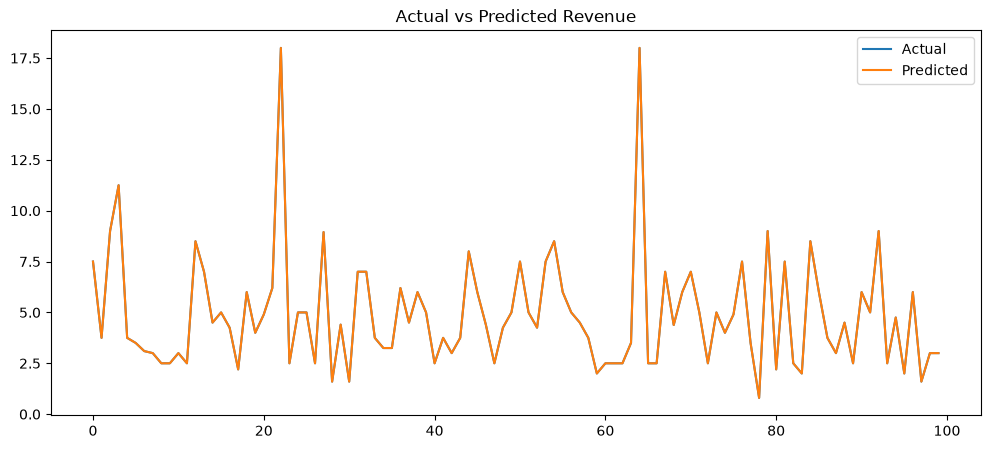

In [19]:
plt.figure(figsize=(12,5))

plt.plot(
    y_test.values[:100],
    label="Actual"
)

plt.plot(
    rf_pred[:100],
    label="Predicted"
)

plt.legend()

plt.title("Actual vs Predicted Revenue")

plt.show()

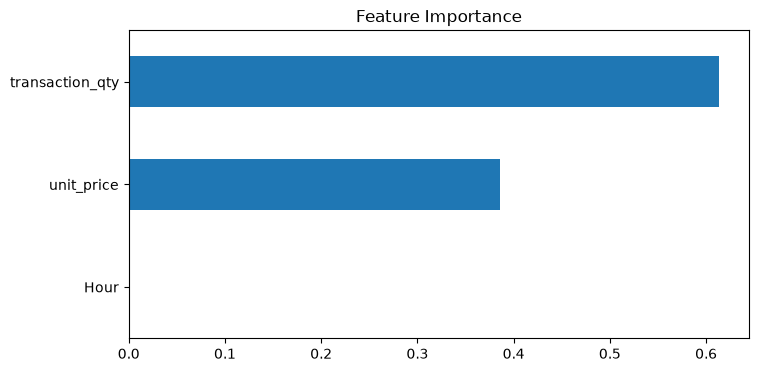

In [20]:
importance = pd.Series(

    rf.feature_importances_,

    index=X.columns

)

importance.sort_values().plot(

    kind="barh",

    figsize=(8,4)

)

plt.title("Feature Importance")

plt.show()